<a href="https://colab.research.google.com/github/bekonad/solar-challenge-week1/blob/eda-benin/notebooks/benin_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from scipy import stats

# Focus columns
cols = ["GHI", "DNI", "DHI", "ModA", "ModB", "WS", "WSgust"]

# Z-score
z_scores = np.abs(stats.zscore(df[cols].dropna()))
outliers = (z_scores > 3).any(axis=1)

# Drop or Impute
df_clean = df[~outliers].copy()
df_clean[cols] = fillna(df_clean[cols].median())
# After cleaning and renaming

# Save cleaned CSV (for local use)
df_clean.to_csv("benin_clean.csv", index=False)


NameError: name 'benin_cleaned_df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("benin.csv", parse_dates=["Timestamp"])
df.info()
df.describe()
df.isna().sum()


Saving benin.csv to benin (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[ns]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525

,0
Timestamp,0
GHI,0
DNI,0
DHI,0
ModA,0
ModB,0
Tamb,0
RH,0
WS,0
WSgust,0


In [ ]:
from scipy import stats

# Focus columns
cols = ["GHI", "DNI", "DHI", "ModA", "ModB", "WS", "WSgust"]

# Z-score
z_scores = np.abs(stats.zscore(df[cols].dropna()))
outliers = (z_scores > 3).any(axis=1)
print(f"Outliers found: {outliers.sum()}")

# Drop or Impute
df_clean = df[~outliers].copy()
df_clean[cols] = df_clean[cols].fillna(df_clean[cols].median())

# Save cleaned CSV (for local use)
df_clean.to_csv("benin_clean.csv", index=False)

Outliers found: 7740


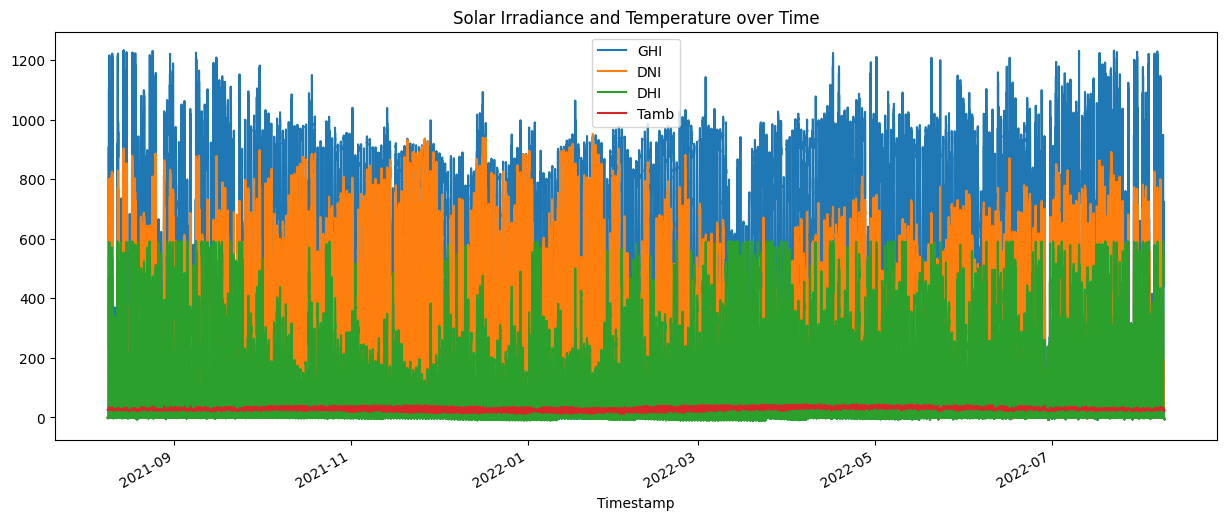

In [ ]:
df_culean.set_index("Timestamp")[["GHI", "DNI", "DHI", "Tamb"]].plot(figsize=(15,6))
plt.title("Solar Irradiance and Temperature over Time")
plt.show()

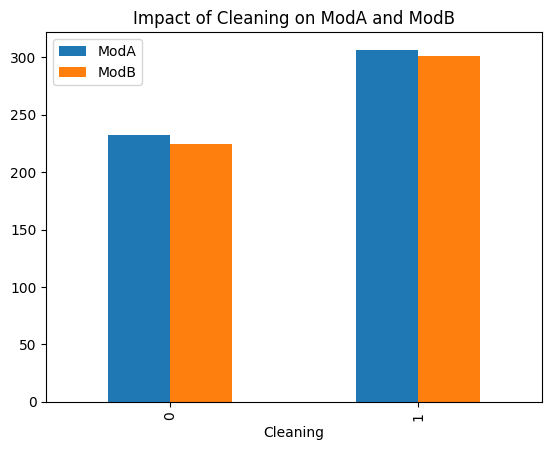

In [ ]:
df_clean["Cleaning"] = df_clean["Cleaning"].fillna(0)
df_clean.groupby("Cleaning")[["ModA", "ModB"]].mean().plot(kind='bar')
plt.title("Impact of Cleaning on ModA and ModB")
plt.show()


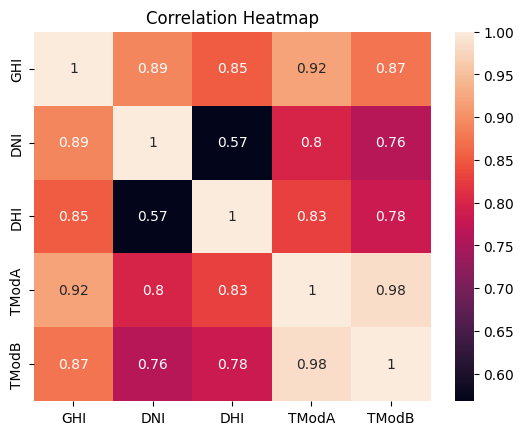

<Axes: xlabel='WS', ylabel='GHI'>

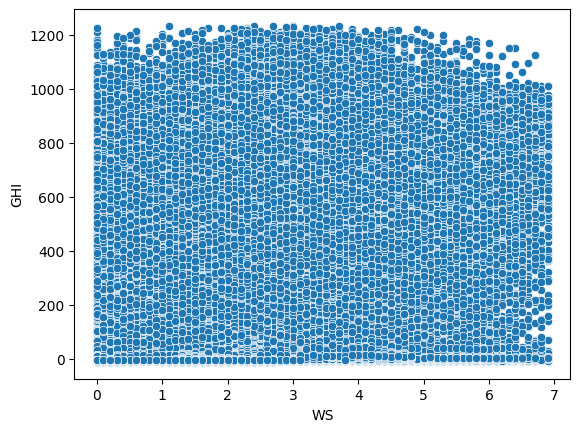

In [ ]:
sns.heatmap(df_clean[["GHI", "DNI", "DHI", "TModA", "TModB"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

sns.scatterplot(x="WS", y="GHI", data=df_clean)

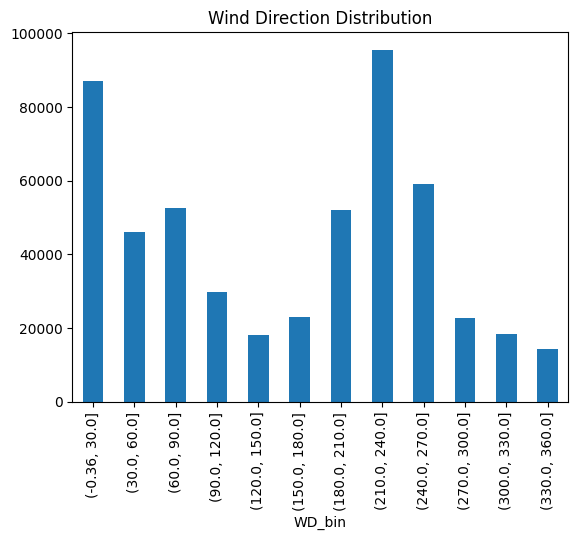

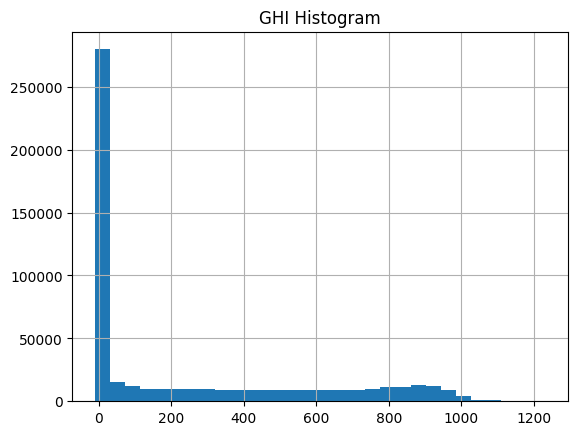

In [ ]:
df_clean["WD_bin"] = pd.cut(df_clean["WD"], bins=12)
df_clean["WD_bin"].value_counts().sort_index().plot(kind='bar')
plt.title("Wind Direction Distribution")
plt.show()

df_clean["GHI"].hist(bins=30)
plt.title("GHI Histogram")
plt.show()

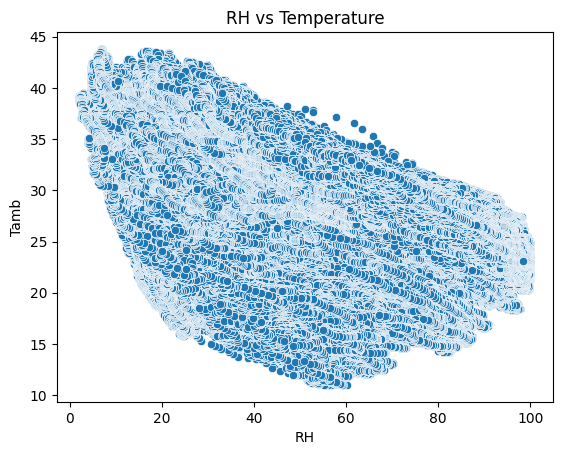

In [ ]:
sns.scatterplot(x="RH", y="Tamb", data=df_clean)
plt.title("RH vs Temperature")
plt.show()

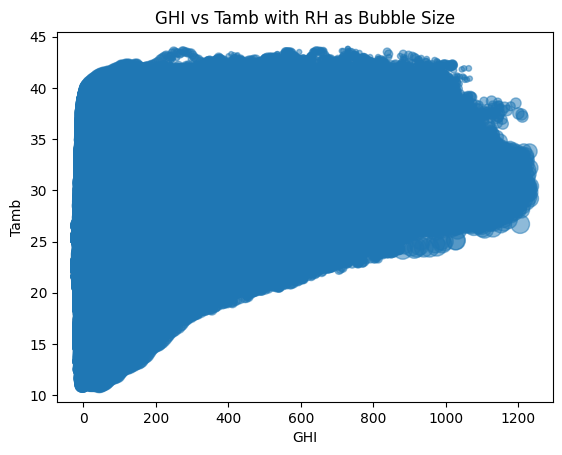

In [ ]:
gplt.scatter(df_clean["GHI"], df_clean["Tamb"], s=df_clean["RH"]*2, alpha=0.5)
plt.title("GHI vs Tamb with RH as Bubble Size")
plt.xlabel("GHI")
plt.ylabel("Tamb")
plt.show()